In [ ]:
import pandas as pd


df = pd.read_csv('/content/online_retail_combined.csv')

print("Dataset shape:", df.shape)
print(df.head())
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (23599, 8)
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  

Columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [ ]:
# Select only numerical columns
X = df.select_dtypes(include=['int64', 'float64']).copy()

print("Numerical columns:")
print(X.columns.tolist())

Numerical columns:
['Quantity', 'Price', 'Customer ID']


In [ ]:
X = X.drop(columns=['CustomerID'], errors='ignore')

In [ ]:
X = X.dropna()

print("Data shape after removing missing values:", X.shape)

Data shape after removing missing values: (17439, 3)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaling completed!")

Scaling completed!


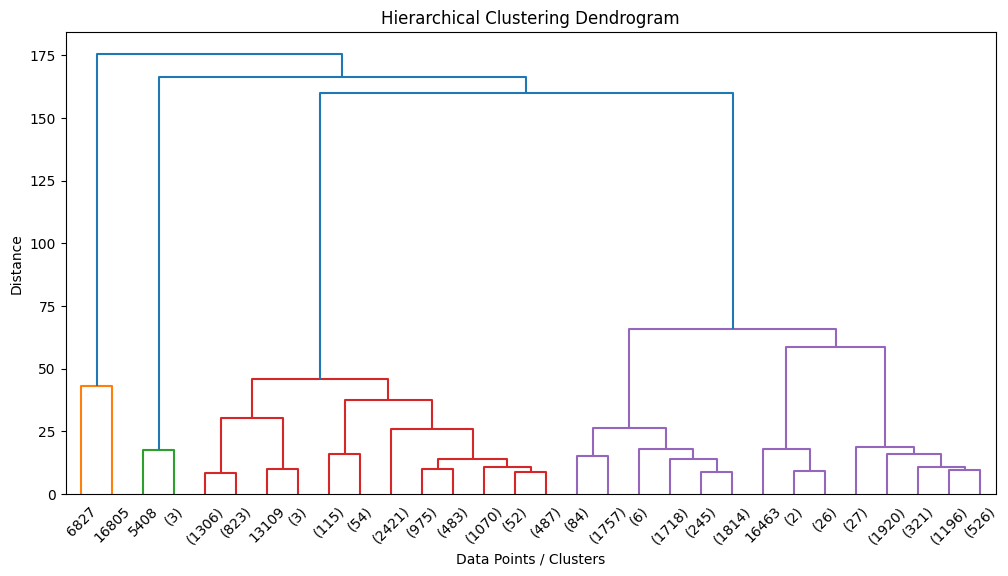

In [ ]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# Create linkage matrix
linked = linkage(
    X_scaled,
    method='ward'
)

# Plot dendrogram
plt.figure(figsize=(12, 6))

dendrogram(
    linked,
    truncate_mode='lastp',
    p=30
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points / Clusters")
plt.ylabel("Distance")

plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(
    n_clusters=4,
    linkage='ward'
)

labels = hierarchical.fit_predict(X_scaled)

print("Cluster labels:")
print(labels)

Cluster labels:
[1 1 1 ... 0 0 0]


In [ ]:
df['Hierarchical_Cluster'] = pd.Series(labels, index=X.index)

print(df.head())

  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  \
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom   
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom   
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom   
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom   
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom   

   Hierarchical_Cluster  
0                   1.0  
1                   1.0  
2                   1.0  
3                   1.0  
4                   1.0  


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("PCA completed!")
print("Explained variance:",
      pca.explained_variance_ratio_)

PCA completed!
Explained variance: [0.34267561 0.32927899]


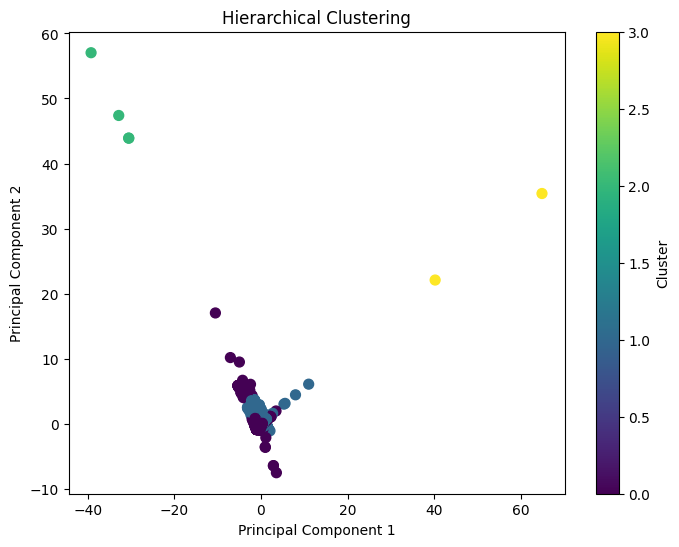

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels,
    s=50
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Hierarchical Clustering")

plt.colorbar(label="Cluster")

plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    X_scaled,
    labels
)

print("Hierarchical Clustering Silhouette Score:",
      score)

Hierarchical Clustering Silhouette Score: 0.5569098702300521


In [ ]:
df.to_csv(
    '/content/online_retail_combined.csv',
    index=False
)

print("Result saved successfully!")

Result saved successfully!


In [15]:
# Select only numerical columns
X = df.select_dtypes(include=['int64', 'float64']).copy()

print("Numerical columns:")
print(X.columns.tolist())

Numerical columns:
['Quantity', 'Price', 'Customer ID', 'Hierarchical_Cluster']


In [16]:
X = X.drop(columns=['CustomerID'], errors='ignore')

In [17]:
X = X.dropna()

print("Data shape after removing missing values:", X.shape)


Data shape after removing missing values: (17439, 4)


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaling completed!")

Scaling completed!


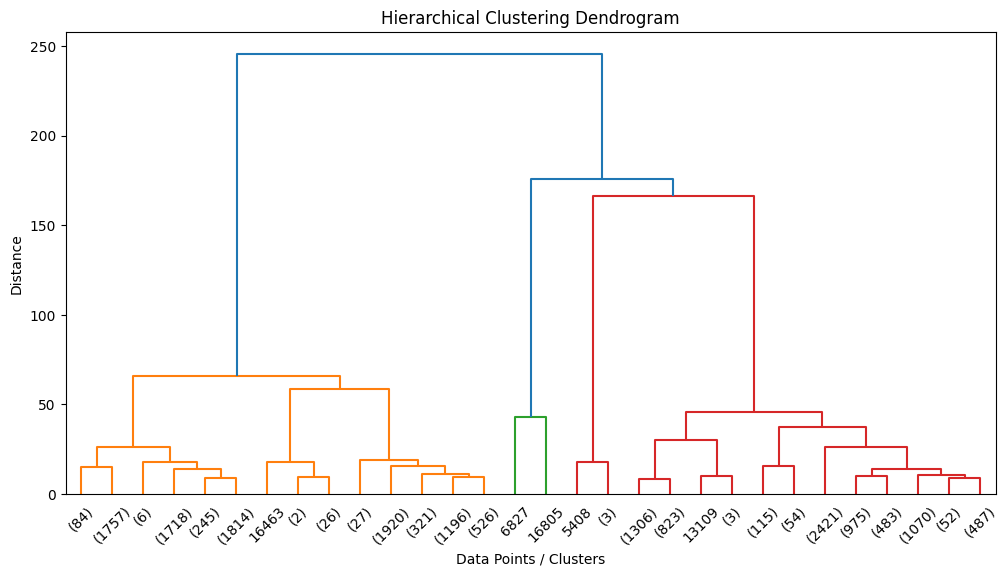

In [19]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# Create linkage matrix
linked = linkage(
    X_scaled,
    method='ward'
)

# Plot dendrogram
plt.figure(figsize=(12, 6))

dendrogram(
    linked,
    truncate_mode='lastp',
    p=30
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points / Clusters")
plt.ylabel("Distance")

plt.show()

In [20]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(
    n_clusters=4,
    linkage='ward'
)

labels = hierarchical.fit_predict(X_scaled)

print("Cluster labels:")
print(labels)

Cluster labels:
[1 1 1 ... 0 0 0]


In [23]:
df['Hierarchical_Cluster'] = pd.Series(labels, index=X.index)

print(df.head())

  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  \
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom   
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom   
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom   
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom   
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom   

   Hierarchical_Cluster  
0                   1.0  
1                   1.0  
2                   1.0  
3                   1.0  
4                   1.0  


In [24]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("PCA completed!")
print("Explained variance:",
      pca.explained_variance_ratio_)

PCA completed!
Explained variance: [0.46413437 0.25330953]


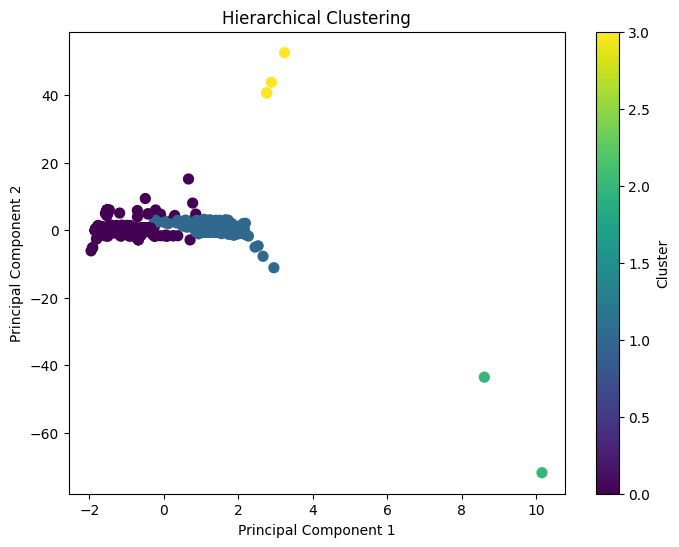

In [25]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels,
    s=50
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Hierarchical Clustering")

plt.colorbar(label="Cluster")

plt.show()

In [26]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    X_scaled,
    labels
)

print("Hierarchical Clustering Silhouette Score:",
      score)

Hierarchical Clustering Silhouette Score: 0.7306536425048035


In [27]:
df.to_csv(
    '/content/hierarchical_clustering_result.csv',
    index=False
)

print("Result saved successfully!")

Result saved successfully!
